In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_dir = "12-way script classification dataset/train_1800"
test_dir = "12-way script classification dataset/test_478"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 12
EPOCHS = 25



In [3]:
def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += len([f for f in files if f.lower().endswith(('png','jpg','jpeg'))])
    return total

total_train_images = count_images(train_dir)
total_test_images = count_images(test_dir)

print("Original Train Images:", total_train_images)
print("Test Images:", total_test_images)

Original Train Images: 21157
Test Images: 5736


In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,   # IMPORTANT: use 1 for splitting
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

Found 21157 files belonging to 12 classes.
Found 5736 files belonging to 12 classes.


In [5]:
def vertical_split(image, label):
    image = tf.squeeze(image, axis=0)   # remove batch dim

    width = tf.shape(image)[1]
    mid = width // 2

    left = image[:, :mid, :]
    right = image[:, mid:, :]

    left = tf.image.resize(left, (IMG_SIZE, IMG_SIZE))
    right = tf.image.resize(right, (IMG_SIZE, IMG_SIZE))

    images = tf.stack([left, right])
    labels = tf.stack([label[0], label[0]])

    return images, labels


train_ds = train_ds.map(vertical_split)
train_ds = train_ds.unbatch()
train_ds = train_ds.batch(BATCH_SIZE)

In [6]:
new_train_size = total_train_images * 2
steps_per_epoch = new_train_size // BATCH_SIZE

validation_steps = total_test_images // BATCH_SIZE

print("Steps per epoch:", steps_per_epoch)

Steps per epoch: 1322


In [7]:
train_ds = train_ds.repeat()
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [9]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

In [10]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

In [13]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1145s 863ms/step - accuracy: 0.2828 - loss: 2.2848 - val_accuracy: 0.3261 - val_loss: 1.9832 - learning_rate: 0.0010
Epoch 2/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1129s 854ms/step - accuracy: 0.3453 - loss: 1.9185 - val_accuracy: 0.3547 - val_loss: 1.8463 - learning_rate: 0.0010
Epoch 3/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1139s 862ms/step - accuracy: 0.3639 - loss: 1.8704 - val_accuracy: 0.3464 - val_loss: 1.8997 - learning_rate: 0.0010
Epoch 4/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1123s 850ms/step - accuracy: 0.3754 - loss: 1.8348 - val_accuracy: 0.3497 - val_loss: 1.8922 - learning_rate: 0.0010
Epoch 5/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1108s 838ms/step - accuracy: 0.3846 - loss: 1.8089 - val_accuracy: 0.3753 - val_loss: 1.7840 - learning_rate: 0.0010
Epoch 6/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1103s 834ms/step - accuracy: 0.3929 - loss: 1.7813 - val_accuracy: 0.3795 - val_loss: 1.8322 - learning_rate: 0.0010
Epoch 7/25
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1110

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1469s 1s/step - accuracy: 0.4173 - loss: 1.7122 - val_accuracy: 0.4035 - val_loss: 1.7058 - learning_rate: 1.0000e-05
Epoch 2/15
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1451s 1s/step - accuracy: 0.4543 - loss: 1.5925 - val_accuracy: 0.4223 - val_loss: 1.6647 - learning_rate: 1.0000e-05
Epoch 3/15
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1444s 1s/step - accuracy: 0.4792 - loss: 1.5177 - val_accuracy: 0.4345 - val_loss: 1.6201 - learning_rate: 1.0000e-05
Epoch 4/15
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1462s 1s/step - accuracy: 0.4983 - loss: 1.4602 - val_accuracy: 0.4522 - val_loss: 1.5886 - learning_rate: 1.0000e-05
Epoch 5/15
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1474s 1s/step - accuracy: 0.5117 - loss: 1.4127 - val_accuracy: 0.4729 - val_loss: 1.5375 - learning_rate: 1.0000e-05
Epoch 6/15
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 1446s 1s/step - accuracy: 0.5337 - loss: 1.3540 - val_accuracy: 0.4714 - val_loss: 1.5582 - learning_rate: 1.0000e-05
Epoch 7/15
1322/1322 ━━━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

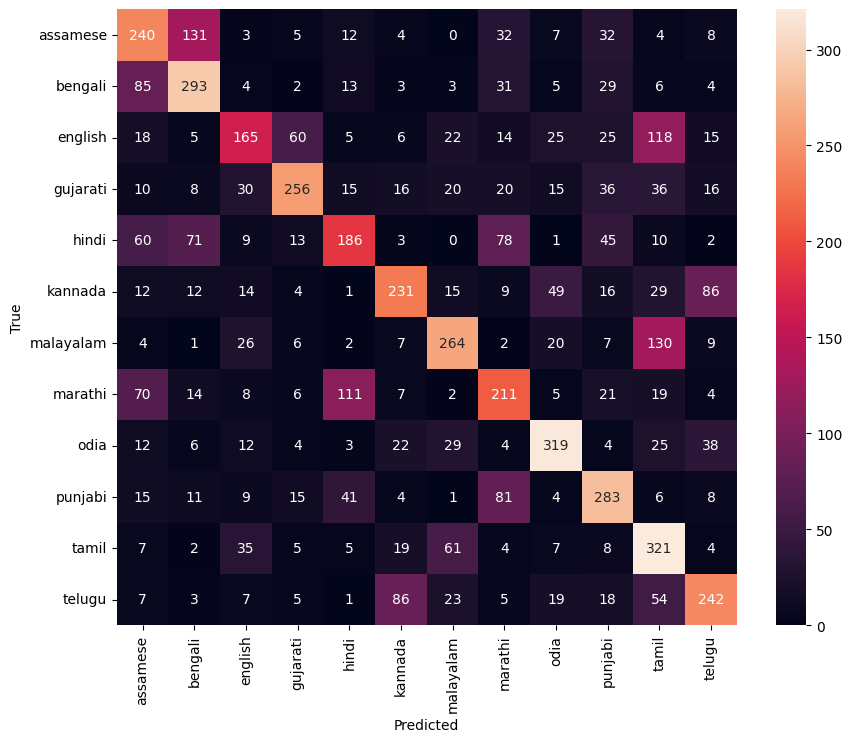

In [15]:
y_true = []
y_pred = []

for images, labels in test_ds.take(validation_steps):
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [16]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    assamese       0.44      0.50      0.47       478
     bengali       0.53      0.61      0.57       478
     english       0.51      0.35      0.41       478
    gujarati       0.67      0.54      0.60       478
       hindi       0.47      0.39      0.43       478
     kannada       0.57      0.48      0.52       478
   malayalam       0.60      0.55      0.58       478
     marathi       0.43      0.44      0.44       478
        odia       0.67      0.67      0.67       478
     punjabi       0.54      0.59      0.56       478
       tamil       0.42      0.67      0.52       478
      telugu       0.56      0.51      0.53       470

    accuracy                           0.53      5728
   macro avg       0.53      0.53      0.52      5728
weighted avg       0.53      0.53      0.52      5728



In [17]:
model.save("bharat_script_resnet50_model.keras")